# ANN (FNN)

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("powerplant_data.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [3]:
# AT => temperature
# V  => vacuum
# AP => pressure
# RH => humidity

# PE => produced energy

In [4]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
X = df.drop(columns = "PE")
y = df["PE"]

In [6]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [7]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [8]:
# Split our data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
df.shape


(9568, 5)

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

In [11]:
X_train_scale

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]],
      shape=(7654, 4))

In [12]:
X_test_scale

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]],
      shape=(1914, 4))

In [13]:
import torch 
import torch.nn as nn

In [14]:
# Creating tensors

X_train_tensor = torch.tensor(X_train_scale, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)  # .values because y_train is a pandas series and .view check notes 

X_test_tensor = torch.tensor(X_test_scale, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

# And these tensors we created are being stored inside our PC - RAM

In [15]:
type(X_train_scale)

numpy.ndarray

In [16]:
type(y_train)

pandas.Series

In [17]:
y_train.shape

(7654,)

In [18]:
# Creating tensordataset and dataloader

from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32)

# Deep Learning starts from here

In [19]:
# Defining our model

class FNN(nn.Module):
    def __init__(self):
        super(FNN, self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6), # in_features, out_features as params
            nn.ReLU(),

            # 2nd hidden layer
            nn.Linear(6, 6),  # in_features, out_features as params
            nn.ReLU(),

            # o/p layer
            nn.Linear(6, 1),  # in_features, out_features as params
        )
    # defining forward prop
    def forward(self, x):
        return self.model(x)
    # we need not have to specify fnx for backward prop because it is inbuilt in torch

In [20]:
import torch.optim as optim

model = FNN()

# loss, optimzer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters()) # params are nothing but the weights and bias etc...

In [21]:
# Train our ANN (Check lecture to understand the flow)

train_losses = []
val_losses = []
best_val_loss = float("inf") # init it with inf so that the one with the minimal will be the best val loss (Check if condition below)
epochs = 50


for epoch in range(epochs):
    # Training
    model.train() # Entered training mode where forward and backward prop.. is carried out
    running_loss = 0.0 # tot training loss for 1 epoch

    for xb, yb in train_dataloader: # b is batch
        # xb = actual i/p of 1 batch
        # yb = actual o/p of 1 batch
        optimizer.zero_grad() # for fresh gradient values everytime
        
        outputs = model(xb) # forward prop... is carried out and we get the predicted o/p for this batch
        loss = crietrion(outputs, yb) # computes the loss by taking the actual o/p and the predicted o/p
        loss.backward() # back prop... gradients are computed
        optimizer.step() # params are updated

        running_loss += loss.item() # loss is a tensor value so we are converting it to python float

    epoch_train_loss = running_loss / len(train_dataloader) # formula check notes
    train_losses.append(epoch_train_loss)

    # Validation (here their is no learning, only predictions)
    model.eval() # Entered validation mode where only forward is present and no backward propagation
    running_loss = 0.0

    with torch.no_grad(): # Dont compute gradients because it is val here there is no backward prop...
        for xb, yb in test_dataloader:
            outputs = model(xb) # forward prop... 
            loss = crietrion(outputs, yb)
    
            running_loss += loss

    epoch_val_loss = running_loss / len(test_dataloader)
    val_losses.append(epoch_val_loss)

    print(f"epoch: {epoch+1} / {epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    # Saving our best model
    if epoch_val_loss < best_val_loss :
        best_val_loss = epoch_val_loss

        torch.save(model.state_dict(), "best_model.pt") # .pt and .pth are the extensions to store the file

epoch: 1 / 50 ==> train loss = 205031.56822916667 & val loss = 201690.359375
epoch: 2 / 50 ==> train loss = 192145.33268229166 & val loss = 177902.328125
epoch: 3 / 50 ==> train loss = 155765.24775390624 & val loss = 130934.3203125
epoch: 4 / 50 ==> train loss = 105564.93359375 & val loss = 83042.2421875
epoch: 5 / 50 ==> train loss = 66638.75826822917 & val loss = 53835.99609375
epoch: 6 / 50 ==> train loss = 43680.60735677083 & val loss = 35267.9375
epoch: 7 / 50 ==> train loss = 27692.19919433594 & val loss = 21319.625
epoch: 8 / 50 ==> train loss = 16202.76668701172 & val loss = 12204.9169921875
epoch: 9 / 50 ==> train loss = 9572.515570068359 & val loss = 7650.900390625
epoch: 10 / 50 ==> train loss = 6371.125644938151 & val loss = 5344.87451171875
epoch: 11 / 50 ==> train loss = 4484.507185872396 & val loss = 3786.0078125
epoch: 12 / 50 ==> train loss = 3179.7933466593427 & val loss = 2743.206787109375
epoch: 13 / 50 ==> train loss = 2350.359112294515 & val loss = 2100.8908691406

In [22]:
# Loading the model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

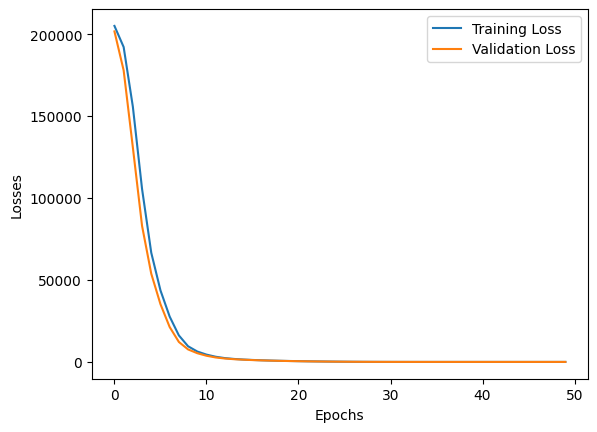

In [23]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss":val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [24]:
# Evaluation
model.eval()
with torch.no_grad():
    train_pred = model(X_train_tensor)
    test_pred = model(X_test_tensor)

    train_mse_loss = crietrion(train_pred, y_train_tensor)
    test_mse_loss = crietrion(test_pred, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 21.27192497253418
Testing MSE: 19.862455368041992


In [25]:
from sklearn.metrics import r2_score

print("r2 score:", r2_score(y_test, test_pred))

r2 score: 0.930585846233143


In [26]:
# Checking actual values and the predicted values.
predicted_df = pd.DataFrame(test_pred.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,435.725677,433.27
1,437.502563,438.16
2,461.080597,458.42
3,475.861603,480.82
4,435.676514,441.41
...,...,...
1909,451.545563,456.70
1910,432.216888,438.04
1911,467.484253,467.80
1912,431.693481,437.14
